
# Predicting Publisher
**Author:** AARON 
**Date:** April 4, 2026 
**Objective:** Create a Randome Forest Model to predict Publisher for articles.




## Introduction
- Using the Random Forest Model Predict which Publisher wrote an article.

# 1. Imports

This section imports the libraries used for:

- data handling
- plotting
- profile comparison
- Random Forest classification
- evaluation metrics

In [33]:
# =========================================================
# 1. IMPORTS
# =========================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

# 2. Define Raw Sentiment Score Columns

These are the sentiment score columns already present in the dataset.

They include:

- keyword/topic sentiment scores
- text-level sentiment scores

These columns form the core article-level input to the publisher prediction model.

In [34]:
# =========================================================
# 2. DEFINE RAW SENTIMENT SCORE COLUMNS
# =========================================================

score_cols = [
    'iran_score',
    'iranian_score',
    'israel_israeli_score',
    'hormuz_score',
    'supreme_leader_score',
    'tehran_score',
    'trump_score',
    'us_united_states_score',
    'title_score',
    'full_text_score',
    'start_text_score',
    'half_text_score',
]

keyword_score_cols = [
    'iran_score',
    'iranian_score',
    'israel_israeli_score',
    'hormuz_score',
    'supreme_leader_score',
    'tehran_score',
    'trump_score',
    'us_united_states_score',
]

text_score_cols = ['title_score', 'full_text_score', 'start_text_score', 'half_text_score']

# 3. Load the Dataset

Load the cleaned dataset and confirm that the expected columns are present.

This notebook assumes the dataset already includes:

- `published_date`
- `publisher`
- the raw sentiment score columns

In [35]:
# =========================================================
# 3. LOAD DATASET
# =========================================================

# Example:
df = pd.read_csv("../code/iran_war_complete_articles_sentiment.csv")

# If df is already loaded in memory, keep a clean copy.
df = df.copy()

# Convert the date column to datetime
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")

print("Dataset shape:", df.shape)
print()
print("Columns preview:")
print(df.columns.tolist())

Dataset shape: (370, 52)

Columns preview:
['Key', 'title', 'headline_length', 'article_word_count', 'author', 'publisher', 'publisher_country', 'publisher_type', 'published_date', 'collection_date', 'link', 'full_text', 'source_type', 'keyword_trigger', 'start_text', 'half_text', 'canonical_link', '_row_id', 'iran_count', 'iran_score', 'iran_sentiment', 'iranian_count', 'iranian_score', 'iranian_sentiment', 'israel_israeli_count', 'israel_israeli_score', 'israel_israeli_sentiment', 'hormuz_count', 'hormuz_score', 'hormuz_sentiment', 'supreme_leader_count', 'supreme_leader_score', 'supreme_leader_sentiment', 'tehran_count', 'tehran_score', 'tehran_sentiment', 'trump_count', 'trump_score', 'trump_sentiment', 'us_united_states_count', 'us_united_states_score', 'us_united_states_sentiment', 'title_score', 'title_sentiment', 'full_text_score', 'full_text_sentiment', 'start_text_score', 'start_text_sentiment', 'half_text_score', 'half_text_sentiment', 'title_article_diff', 'title_article_di

# 4. Basic Cleaning

This section:

- removes rows missing required fields
- sorts the dataset by date
- checks class distribution

Sorting by date is required for true walk-forward prediction.

In [36]:
# =========================================================
# 4. BASIC CLEANING
# =========================================================

required_cols = ["published_date", "publisher"] + score_cols

df = df.dropna(subset=required_cols).copy()
df = df.sort_values("published_date").reset_index(drop=True)

print("Rows after cleaning:", len(df))
print()
print("Publisher counts:")
print(df["publisher"].value_counts())

Rows after cleaning: 370

Publisher counts:
publisher
Al Jazeera    118
BBC            95
NBC News       89
Fox News       68
Name: count, dtype: int64


# 5. Add Article-Level Features

This section creates additional article-level features from the raw score columns.

These features summarize:

- average keyword tone
- average text tone
- variation in sentiment
- differences between title and body sentiment
- simple calendar features

In [37]:
# =========================================================
# 5. ADD ARTICLE-LEVEL FEATURES
# =========================================================


def add_article_features(df):
    """
    Create derived article-level features from the raw sentiment columns.
    These features help summarize the article's sentiment pattern.
    """
    df = df.copy()

    # ---- Aggregate summaries ----
    df["keyword_avg"] = df[keyword_score_cols].mean(axis=1)
    df["keyword_std"] = df[keyword_score_cols].std(axis=1)

    df["text_avg"] = df[text_score_cols].mean(axis=1)
    df["text_std"] = df[text_score_cols].std(axis=1)

    # ---- Differences across text-level fields ----
    df["title_vs_full"] = df["title_score"] - df["full_text_score"]
    df["title_vs_start"] = df["title_score"] - df["start_text_score"]
    df["title_vs_half"] = df["title_score"] - df["half_text_score"]
    df["start_vs_half"] = df["start_text_score"] - df["half_text_score"]

    # ---- Overall spread across all sentiment fields ----
    df["score_range"] = df[score_cols].max(axis=1) - df[score_cols].min(axis=1)
    df["score_mean"] = df[score_cols].mean(axis=1)
    df["score_std_all"] = df[score_cols].std(axis=1)

    # ---- Calendar/time features ----
    df["dayofweek"] = df["published_date"].dt.dayofweek
    df["month"] = df["published_date"].dt.month
    df["dayofmonth"] = df["published_date"].dt.day

    return df


df = add_article_features(df)

print("Dataset shape after feature engineering:", df.shape)
df.head()

Dataset shape after feature engineering: (370, 66)


,Key,title,headline_length,article_word_count,author,publisher,publisher_country,publisher_type,published_date,collection_date,...,title_vs_full,title_vs_start,title_vs_half,start_vs_half,score_range,score_mean,score_std_all,dayofweek,month,dayofmonth
0,1018,Stranded American in Bahrain recounts survivin...,110,763,Bonny Chu,Fox News,US,Cable News,2026-03-10,3/14/2026,...,1.2143,1.4634,1.4392,-0.0242,1.9972,-0.024433,0.702793,1,3,10
1,7016,Lethal elite 'black-clad' kill squad guards Ir...,86,627,Emma Bussey,Fox News,US,Cable News,2026-03-10,3/15/2026,...,-0.8929,-0.7266,-0.9248,-0.1982,1.9741,-0.106158,0.562367,1,3,10
2,1017,Putin caught executing enormous 'semi-dark' sh...,85,450,Emma Bussey,Fox News,US,Cable News,2026-03-10,3/14/2026,...,-0.2878,-0.2037,-0.2878,-0.0841,1.9867,-0.278117,0.555886,1,3,10
3,2020,Why Vladimir Putin may be the big winner in Tr...,60,1078,Yuliya Talmazan,NBC News,US,Broadcast Network,2026-03-10,3/15/2026,...,1.1347,1.1071,0.8464,-0.2607,1.9955,0.195625,0.578196,1,3,10
4,7015,Failed download,15,699,Emma Bussey,Fox News,US,Cable News,2026-03-10,3/15/2026,...,-0.2767,-0.3656,-0.2170,0.1486,0.9995,-0.568892,0.437675,1,3,10


# 6. Helper Function for Safe Publisher Names

Publisher names may contain spaces or punctuation.

This helper function converts them into safe text that can be used in feature names.

In [38]:
# =========================================================
# 6. HELPER FUNCTION FOR SAFE FEATURE NAMES
# =========================================================


def safe_name(name):
    """
    Convert publisher names into safe strings for column names.
    Example:
    'Al Jazeera' -> 'Al_Jazeera'
    """
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(name)).strip("_")

# 7. Build Publisher Profiles

This section defines how publisher profiles are created.

Two profiles are used:

- long-term profile: all prior articles
- short-term profile: recent prior articles from the last few days

These profiles are built only from data available before the prediction day.

In [39]:
# =========================================================
# 7. BUILD SHORT-TERM AND LONG-TERM PUBLISHER PROFILES
# =========================================================


def build_profiles(train_df, score_cols, current_day, short_window_days=5):
    """
    Build long-term and short-term publisher sentiment profiles
    using ONLY data before the prediction day.
    """
    train_df = train_df.copy()

    # Long-term profile = mean of all prior data
    long_profiles = train_df.groupby("publisher")[score_cols].mean()

    # Short-term profile = mean of recent prior data only
    cutoff = pd.Timestamp(current_day) - pd.Timedelta(days=short_window_days)
    train_recent = train_df[train_df["published_date"] >= cutoff].copy()

    short_profiles = train_recent.groupby("publisher")[score_cols].mean()

    return long_profiles, short_profiles

# 8. Add Profile Comparison Features

For each article, compare its sentiment vector to each publisher's:

- long-term profile
- short-term profile

The comparison features include:

- Euclidean distance
- cosine similarity
- the gap between short-term and long-term distance

In [40]:
# =========================================================
# 8. ADD PROFILE COMPARISON FEATURES
# =========================================================


def add_profile_features(df_part, long_profiles, short_profiles, score_cols):
    """
    Compare each article to each publisher's long-term and short-term profile.

    Features added:
    - distance to each long-term profile
    - cosine similarity to each long-term profile
    - distance to each short-term profile
    - cosine similarity to each short-term profile
    - gap between short-term and long-term distance
    """
    df_part = df_part.copy()

    article_matrix = df_part[score_cols].values

    for pub in long_profiles.index:
        safe_pub = safe_name(pub)

        # ----- Long-term profile -----
        long_vec = long_profiles.loc[pub, score_cols].values.reshape(1, -1)

        df_part[f"dist_long_{safe_pub}"] = np.linalg.norm(article_matrix - long_vec, axis=1)
        df_part[f"cos_long_{safe_pub}"] = cosine_similarity(article_matrix, long_vec).flatten()

        # ----- Short-term profile -----
        if pub in short_profiles.index:
            short_vec = short_profiles.loc[pub, score_cols].values.reshape(1, -1)

            df_part[f"dist_short_{safe_pub}"] = np.linalg.norm(article_matrix - short_vec, axis=1)
            df_part[f"cos_short_{safe_pub}"] = cosine_similarity(
                article_matrix, short_vec
            ).flatten()
        else:
            # If there is no recent profile for a publisher, use defaults
            df_part[f"dist_short_{safe_pub}"] = np.nan
            df_part[f"cos_short_{safe_pub}"] = 0.0

        # ----- Difference between short-term and long-term distance -----
        df_part[f"dist_gap_{safe_pub}"] = (
            df_part[f"dist_short_{safe_pub}"] - df_part[f"dist_long_{safe_pub}"]
        )

    return df_part

# 9. Define Base Feature Columns

These are the features always used in the model before adding profile comparison features.

In [41]:
# =========================================================
# 9. DEFINE BASE FEATURE COLUMNS
# =========================================================

base_feature_cols = score_cols + [
    "keyword_avg",
    "keyword_std",
    "text_avg",
    "text_std",
    "title_vs_full",
    "title_vs_start",
    "title_vs_half",
    "start_vs_half",
    "score_range",
    "score_mean",
    "score_std_all",
    "dayofweek",
    "month",
    "dayofmonth",
]

print("Base feature count:", len(base_feature_cols))
print(base_feature_cols)

Base feature count: 26
['iran_score', 'iranian_score', 'israel_israeli_score', 'hormuz_score', 'supreme_leader_score', 'tehran_score', 'trump_score', 'us_united_states_score', 'title_score', 'full_text_score', 'start_text_score', 'half_text_score', 'keyword_avg', 'keyword_std', 'text_avg', 'text_std', 'title_vs_full', 'title_vs_start', 'title_vs_half', 'start_vs_half', 'score_range', 'score_mean', 'score_std_all', 'dayofweek', 'month', 'dayofmonth']


# 10. Define the Daily Walk-Forward Prediction Function

This is the core live prediction function.

For each day, it:

1. trains on all prior days
2. builds publisher profiles using prior days only
3. predicts the publisher for the current day
4. records daily accuracy and F1 scores

This is a true live prediction setup because the current day's publisher is never used as an input.

In [42]:
# =========================================================
# 10. DAILY WALK-FORWARD LIVE PREDICTION FUNCTION
# =========================================================


def run_daily_live_prediction(df, score_cols, short_window_days=5, min_train_rows=20):
    """
    Perform true live daily prediction of publisher.

    For each prediction day:
    - train on all prior days
    - build long-term and short-term publisher profiles from prior days only
    - compare articles on the current day to those profiles
    - predict publisher
    - store metrics and predictions
    """
    df = df.copy().sort_values("published_date")

    all_days = sorted(df["published_date"].dt.date.unique())
    results = []
    prediction_frames = []

    last_model = None
    last_feature_cols = None
    last_test_feat = None
    last_y_test = None
    last_preds = None

    for day in all_days[1:]:
        # ----- Split into prior training data and current-day test data -----
        train = df[df["published_date"].dt.date < day].copy()
        test = df[df["published_date"].dt.date == day].copy()

        if len(train) < min_train_rows or len(test) == 0:
            continue

        # ----- Build profiles from prior training data only -----
        long_profiles, short_profiles = build_profiles(
            train_df=train,
            score_cols=score_cols,
            current_day=day,
            short_window_days=short_window_days,
        )

        if long_profiles.shape[0] < 2:
            continue

        # ----- Add profile comparison features -----
        train_feat = add_profile_features(train, long_profiles, short_profiles, score_cols)
        test_feat = add_profile_features(test, long_profiles, short_profiles, score_cols)

        # Fill missing values that may occur if a short-term profile is unavailable
        train_feat = train_feat.fillna(0)
        test_feat = test_feat.fillna(0)

        # ----- Collect profile feature columns -----
        profile_feature_cols = [
            c
            for c in train_feat.columns
            if c.startswith("dist_long_")
            or c.startswith("cos_long_")
            or c.startswith("dist_short_")
            or c.startswith("cos_short_")
            or c.startswith("dist_gap_")
        ]

        feature_cols = base_feature_cols + profile_feature_cols

        X_train = train_feat[feature_cols]
        y_train = train_feat["publisher"]

        X_test = test_feat[feature_cols]
        y_test = test_feat["publisher"]

        # ----- Main model -----
        model = RandomForestClassifier(
            n_estimators=300, max_depth=10, class_weight="balanced", random_state=42
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # ----- Store daily metrics -----
        results.append(
            {
                "day": day,
                "n_articles": len(test),
                "accuracy": accuracy_score(y_test, preds),
                "macro_f1": f1_score(y_test, preds, average="macro"),
                "weighted_f1": f1_score(y_test, preds, average="weighted"),
            }
        )

        # ----- Store row-level predictions -----
        pred_df = test_feat[["published_date", "publisher"]].copy()
        pred_df["predicted_publisher"] = preds
        pred_df["prediction_day"] = day
        prediction_frames.append(pred_df)

        # Save most recent model and test set for later inspection
        last_model = model
        last_feature_cols = feature_cols
        last_test_feat = test_feat
        last_y_test = y_test
        last_preds = preds

    results_df = pd.DataFrame(results)

    if prediction_frames:
        predictions_df = pd.concat(prediction_frames, ignore_index=True)
    else:
        predictions_df = pd.DataFrame()

    return (
        results_df,
        predictions_df,
        last_model,
        last_feature_cols,
        last_test_feat,
        last_y_test,
        last_preds,
    )

# 11. Run the Model

Run the daily walk-forward prediction pipeline.

You can change `short_window_days` to compare 3, 4, or 5 day short-term profiles.

In [43]:
# =========================================================
# 11. RUN THE MODEL
# =========================================================

(results_df, predictions_df, model, feature_cols, last_test_feat, last_y_test, last_preds) = (
    run_daily_live_prediction(df=df, score_cols=score_cols, short_window_days=5, min_train_rows=20)
)

print(results_df.head())
print()
print("Number of prediction days:", len(results_df))

          day  n_articles  accuracy  macro_f1  weighted_f1
0  2026-03-14          28  0.178571  0.152339     0.123306
1  2026-03-15          37  0.297297  0.292839     0.281053
2  2026-03-16          31  0.419355  0.408300     0.414229
3  2026-03-17          30  0.233333  0.215097     0.235390
4  2026-03-18          27  0.333333  0.337753     0.345118

Number of prediction days: 14


# 12. View the Latest Day's Metrics

This shows the model's most recent daily performance.

In [44]:
# =========================================================
# 12. VIEW LATEST DAY'S METRICS
# =========================================================

if not results_df.empty:
    latest_day = results_df["day"].max()
    latest_day_result = results_df[results_df["day"] == latest_day]

    print("Latest prediction day:")
    print(latest_day_result)
else:
    print("No daily results were generated.")

Latest prediction day:
           day  n_articles  accuracy  macro_f1  weighted_f1
13  2026-03-27          28  0.464286  0.403247     0.452257


# 13. Plot Daily Accuracy Over Time

This visualization shows how live prediction accuracy changes across days.

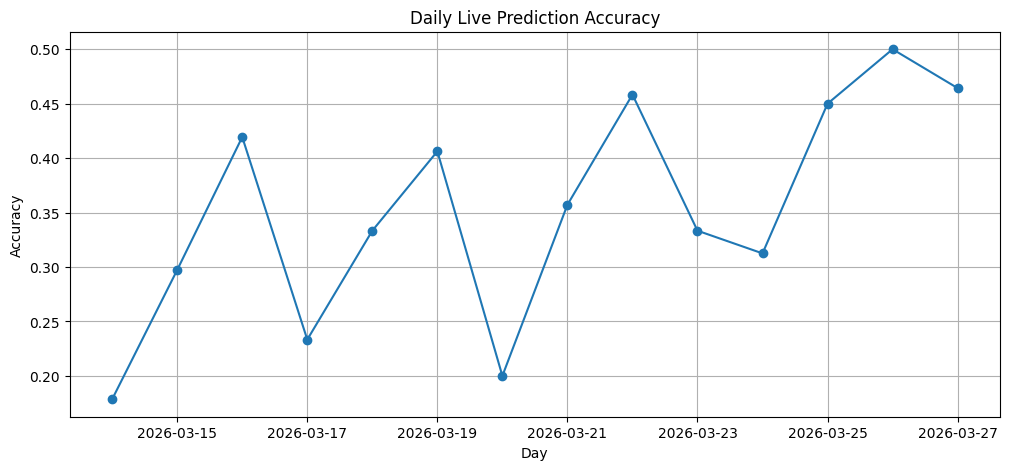

In [45]:
# =========================================================
# 13. PLOT DAILY ACCURACY OVER TIME
# =========================================================

if not results_df.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(results_df["day"]), results_df["accuracy"], marker="o")
    plt.title("Daily Live Prediction Accuracy")
    plt.xlabel("Day")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.show()

# 14. Classification Report for the Latest Day

This gives:

- precision
- recall
- F1-score

for each publisher on the most recent prediction day.

In [46]:
# =========================================================
# 14. CLASSIFICATION REPORT FOR LATEST DAY
# =========================================================

if last_y_test is not None and last_preds is not None:
    print(classification_report(last_y_test, last_preds))
else:
    print("No latest-day predictions available.")

              precision    recall  f1-score   support

  Al Jazeera       0.67      0.80      0.73        10
         BBC       0.50      0.25      0.33         8
    Fox News       0.25      0.33      0.29         3
    NBC News       0.25      0.29      0.27         7

    accuracy                           0.46        28
   macro avg       0.42      0.42      0.40        28
weighted avg       0.47      0.46      0.45        28



# 15. Confusion Matrix for the Latest Day

This plot shows which publishers are most often confused with each other.

<Figure size 800x600 with 0 Axes>

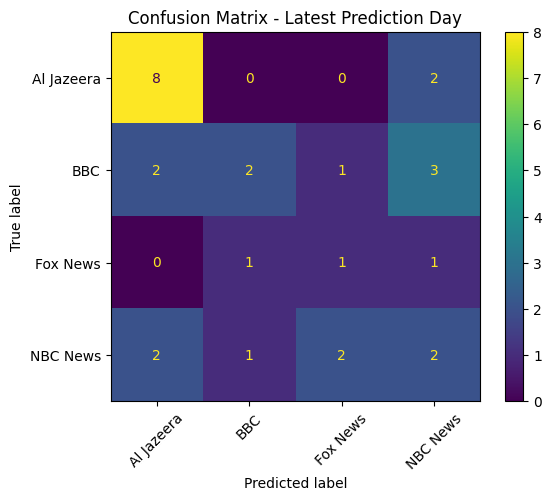

In [47]:
# =========================================================
# 15. CONFUSION MATRIX FOR LATEST DAY
# =========================================================

if model is not None and last_test_feat is not None and feature_cols is not None:
    plt.figure(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator(
        model, last_test_feat[feature_cols], last_y_test, xticks_rotation=45
    )
    plt.title("Confusion Matrix - Latest Prediction Day")
    plt.show()
else:
    print("No model/test set available for confusion matrix.")

# 16. Visualize How Publisher Profiles Shift Over Time

This section plots:

- short-term profile
- long-term profile

for each publisher using `keyword_avg` as a summary signal.

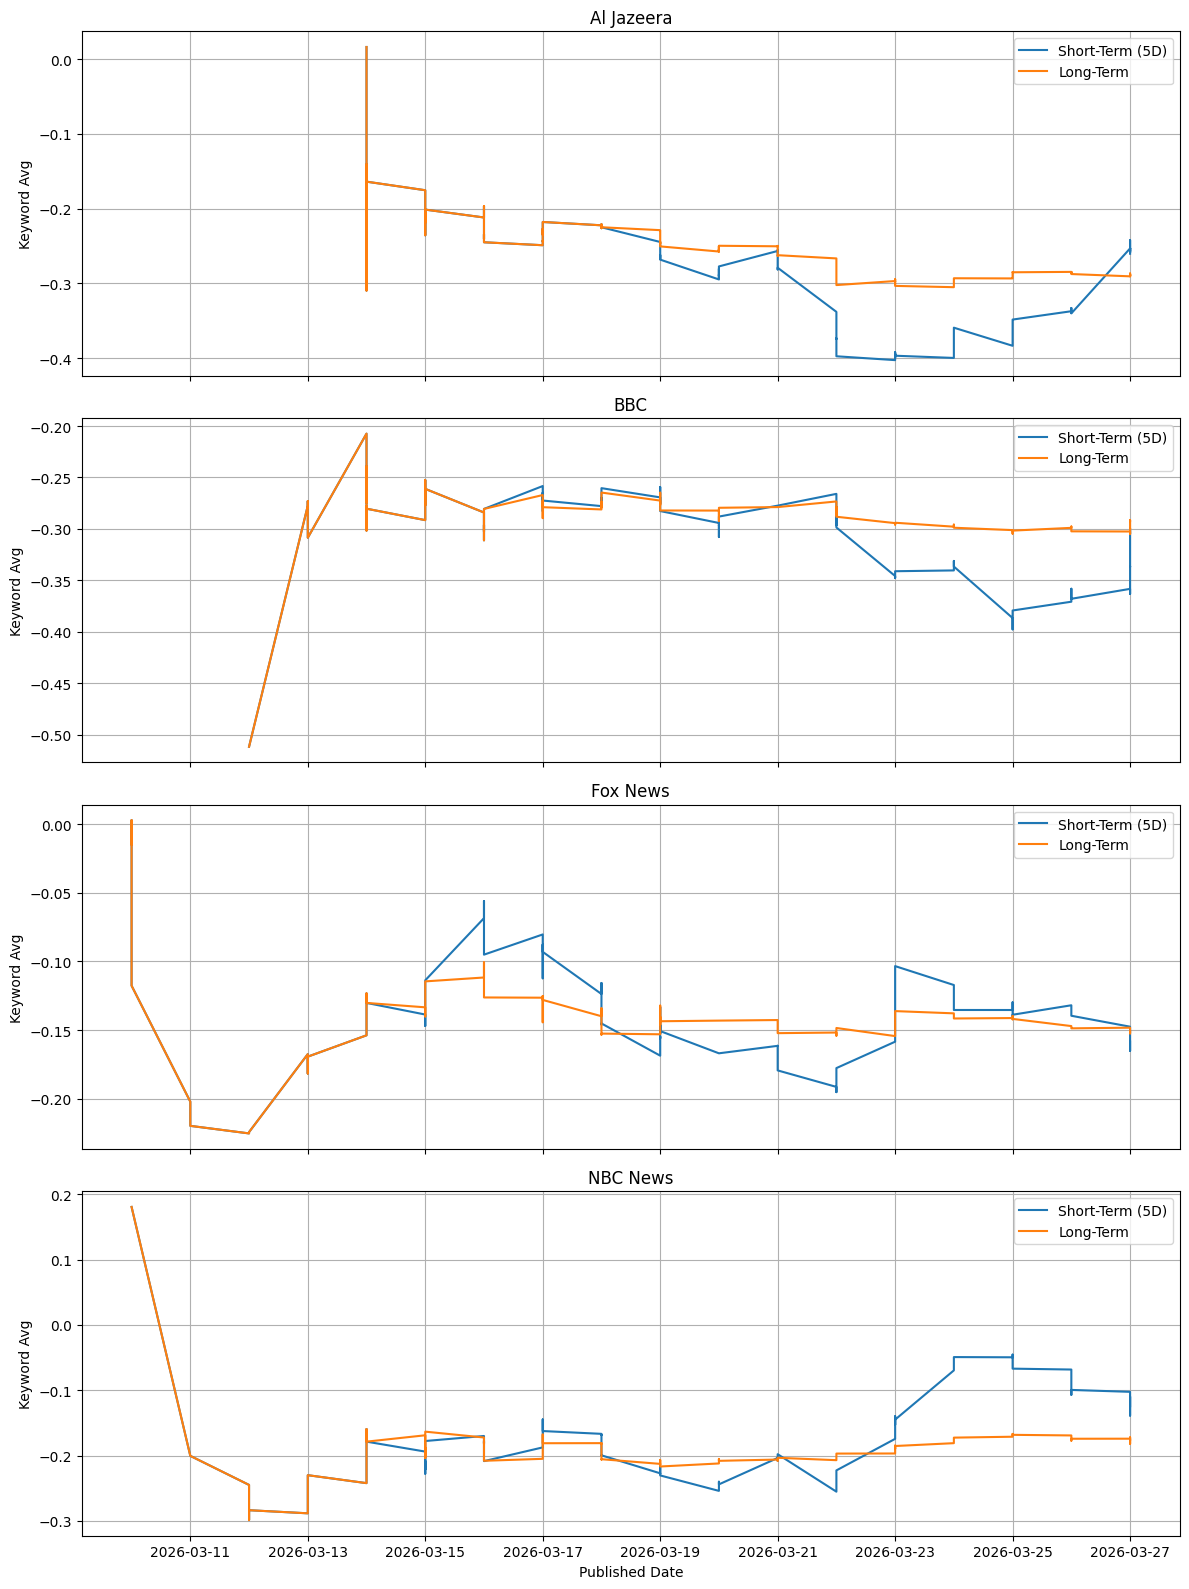

In [48]:
# =========================================================
# 16. VISUALIZE HOW PUBLISHER PROFILES SHIFT OVER TIME
# =========================================================


def compute_profile_over_time(df, publisher, score_col="keyword_avg", window_days=5):
    """
    Compute a short-term rolling profile and a long-term expanding profile
    for one publisher over time.
    """
    df_pub = df[df["publisher"] == publisher].sort_values("published_date").copy()

    short_series = df_pub.set_index("published_date")[score_col].rolling(f"{window_days}D").mean()

    df_pub["short_term"] = short_series.values
    df_pub["long_term"] = df_pub[score_col].expanding().mean()

    return df_pub


publishers = sorted(df["publisher"].unique())

fig, axes = plt.subplots(len(publishers), 1, figsize=(12, 4 * len(publishers)), sharex=True)

if len(publishers) == 1:
    axes = [axes]

for i, pub in enumerate(publishers):
    df_pub = compute_profile_over_time(df, publisher=pub, score_col="keyword_avg", window_days=5)

    axes[i].plot(df_pub["published_date"], df_pub["short_term"], label="Short-Term (5D)")
    axes[i].plot(df_pub["published_date"], df_pub["long_term"], label="Long-Term")
    axes[i].set_title(pub)
    axes[i].set_ylabel("Keyword Avg")
    axes[i].legend()
    axes[i].grid(True)

plt.xlabel("Published Date")
plt.tight_layout()
plt.show()

# 17. Overall Feature Importance

This section shows which features had the largest influence on the latest trained Random Forest model.

Top 20 overall features:
us_united_states_score    0.037735
israel_israeli_score      0.032201
iran_score                0.029212
iranian_score             0.029210
keyword_avg               0.029046
start_vs_half             0.029036
dist_gap_Fox_News         0.028957
dist_gap_BBC              0.028424
text_std                  0.027771
keyword_std               0.027040
dist_short_BBC            0.025133
title_score               0.024752
title_vs_half             0.024661
dayofmonth                0.022460
dist_gap_NBC_News         0.022240
dist_gap_Al_Jazeera       0.022130
half_text_score           0.022083
cos_long_BBC              0.022044
cos_long_Fox_News         0.021997
title_vs_start            0.021735
dtype: float64


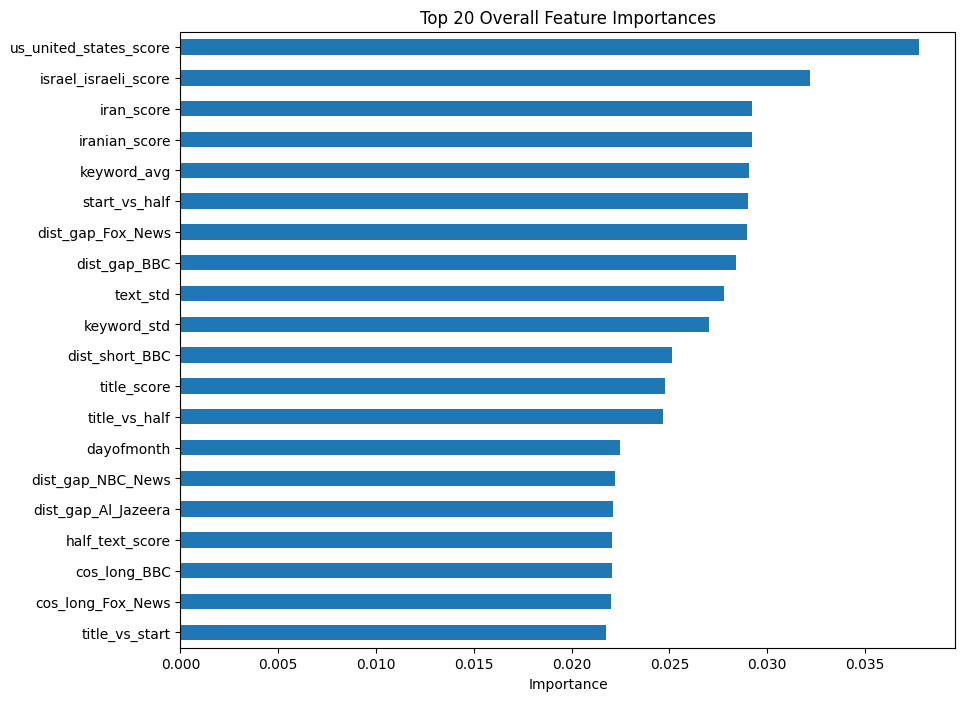

In [49]:
# =========================================================
# 17. OVERALL FEATURE IMPORTANCE
# =========================================================

if model is not None and feature_cols is not None:
    importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(
        ascending=False
    )

    print("Top 20 overall features:")
    print(importance.head(20))

    plt.figure(figsize=(10, 8))
    importance.head(20).sort_values().plot(kind="barh")
    plt.title("Top 20 Overall Feature Importances")
    plt.xlabel("Importance")
    plt.show()
else:
    print("Model or feature columns not available.")

# 18. Feature Importance by Category

This groups feature importance into broader categories such as:

- raw sentiment
- short-term distance
- long-term similarity
- derived article features
- calendar features

category
Raw Sentiment               0.282591
Derived Article Features    0.263012
Short-vs-Long Gap           0.101750
Short-Term Distance         0.081631
Short-Term Similarity       0.080806
Long-Term Similarity        0.079220
Long-Term Distance          0.074724
Calendar Features           0.036266
Name: importance, dtype: float64


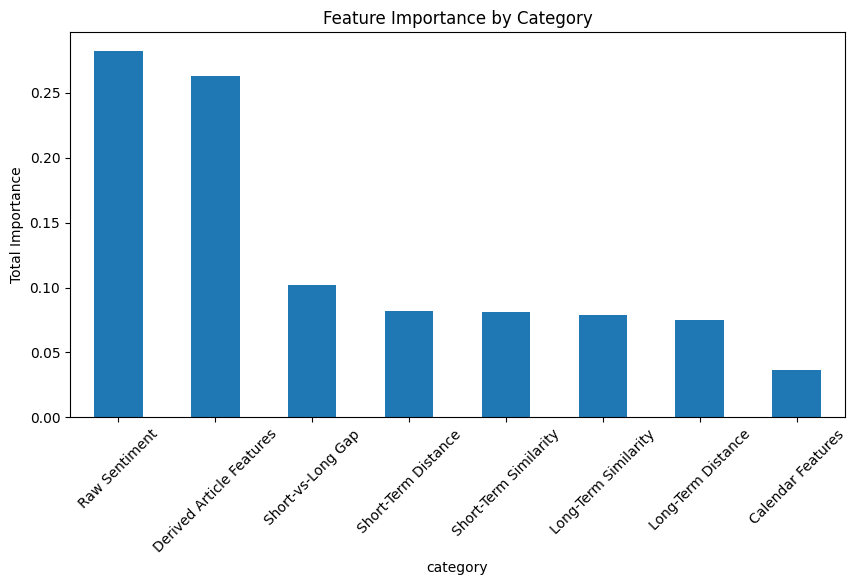

In [50]:
# =========================================================
# 18. FEATURE IMPORTANCE BY CATEGORY
# =========================================================


def categorize_feature(col):
    """
    Assign each feature to a broad category for easier interpretation.
    """
    if col.startswith("dist_short_"):
        return "Short-Term Distance"
    elif col.startswith("dist_long_"):
        return "Long-Term Distance"
    elif col.startswith("cos_short_"):
        return "Short-Term Similarity"
    elif col.startswith("cos_long_"):
        return "Long-Term Similarity"
    elif col.startswith("dist_gap_"):
        return "Short-vs-Long Gap"
    elif col in score_cols:
        return "Raw Sentiment"
    elif col in [
        "keyword_avg",
        "keyword_std",
        "text_avg",
        "text_std",
        "title_vs_full",
        "title_vs_start",
        "title_vs_half",
        "start_vs_half",
        "score_range",
        "score_mean",
        "score_std_all",
    ]:
        return "Derived Article Features"
    elif col in ["dayofweek", "month", "dayofmonth"]:
        return "Calendar Features"
    else:
        return "Other"


if model is not None and feature_cols is not None:
    importance_df = pd.DataFrame(
        {"feature": feature_cols, "importance": model.feature_importances_}
    )

    importance_df["category"] = importance_df["feature"].apply(categorize_feature)

    category_importance = (
        importance_df.groupby("category")["importance"].sum().sort_values(ascending=False)
    )

    print(category_importance)

    plt.figure(figsize=(10, 5))
    category_importance.plot(kind="bar")
    plt.title("Feature Importance by Category")
    plt.ylabel("Total Importance")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Model or feature columns not available.")

# 19. Define Publisher-Specific Feature Importance Function

This section creates one-vs-rest models so you can see which features are most helpful for identifying each publisher separately.

In [51]:
# =========================================================
# 19. PUBLISHER-SPECIFIC FEATURE IMPORTANCE FUNCTION
# =========================================================


def fit_one_vs_rest_feature_importance(train_df, feature_cols):
    """
    Train one-vs-rest Random Forest models for each publisher.
    This helps identify which features are most useful
    for recognizing each publisher individually.
    """
    publisher_importance = {}

    X_train = train_df[feature_cols]
    y_train = train_df["publisher"]

    for pub in sorted(y_train.unique()):
        y_binary = (y_train == pub).astype(int)

        model_bin = RandomForestClassifier(
            n_estimators=200, max_depth=10, class_weight="balanced", random_state=42
        )

        model_bin.fit(X_train, y_binary)

        publisher_importance[pub] = pd.Series(
            model_bin.feature_importances_, index=feature_cols
        ).sort_values(ascending=False)

    return publisher_importance

# 20. Compute Publisher-Specific Feature Importance

This rebuilds the latest training set and fits one-vs-rest models for each publisher.

In [52]:
# =========================================================
# 20. COMPUTE PUBLISHER-SPECIFIC IMPORTANCE
# =========================================================

if not results_df.empty:
    latest_day = results_df["day"].max()

    train_latest = df[df["published_date"].dt.date < latest_day].copy()

    long_profiles, short_profiles = build_profiles(
        train_df=train_latest, score_cols=score_cols, current_day=latest_day, short_window_days=5
    )

    train_latest_feat = add_profile_features(
        train_latest, long_profiles, short_profiles, score_cols
    )
    train_latest_feat = train_latest_feat.fillna(0)

    profile_feature_cols = [
        c
        for c in train_latest_feat.columns
        if c.startswith("dist_long_")
        or c.startswith("cos_long_")
        or c.startswith("dist_short_")
        or c.startswith("cos_short_")
        or c.startswith("dist_gap_")
    ]

    feature_cols_latest = base_feature_cols + profile_feature_cols

    publisher_importance = fit_one_vs_rest_feature_importance(
        train_df=train_latest_feat, feature_cols=feature_cols_latest
    )

    print("Computed publisher-specific feature importance.")
else:
    publisher_importance = {}
    print("No results available.")

Computed publisher-specific feature importance.


# 21. Show the Top Features for Each Publisher

This prints the most important identifying features for each publisher.

In [53]:
# =========================================================
# 21. SHOW TOP FEATURES FOR EACH PUBLISHER
# =========================================================

if publisher_importance:
    for pub, imp in publisher_importance.items():
        print(f"\nTop 10 features for {pub}:")
        print(imp.head(10))
else:
    print("Publisher-specific importance not available.")


Top 10 features for Al Jazeera:
israel_israeli_score      0.044461
us_united_states_score    0.035984
start_vs_half             0.030300
cos_short_BBC             0.027348
dayofmonth                0.026889
score_range               0.026731
cos_long_BBC              0.026293
keyword_avg               0.026169
score_std_all             0.025255
dist_short_Fox_News       0.025216
dtype: float64

Top 10 features for BBC:
us_united_states_score    0.041506
dist_long_BBC             0.033056
title_score               0.031144
israel_israeli_score      0.030983
text_std                  0.029416
title_vs_half             0.028745
start_vs_half             0.028260
dist_gap_BBC              0.028184
iran_score                0.028119
hormuz_score              0.027838
dtype: float64

Top 10 features for Fox News:
dist_gap_BBC              0.051942
keyword_avg               0.037742
us_united_states_score    0.034802
iranian_score             0.032231
iran_score                0.031811
dist_

# 22. Plot the Top Features for One Publisher

Choose one publisher to visualize.

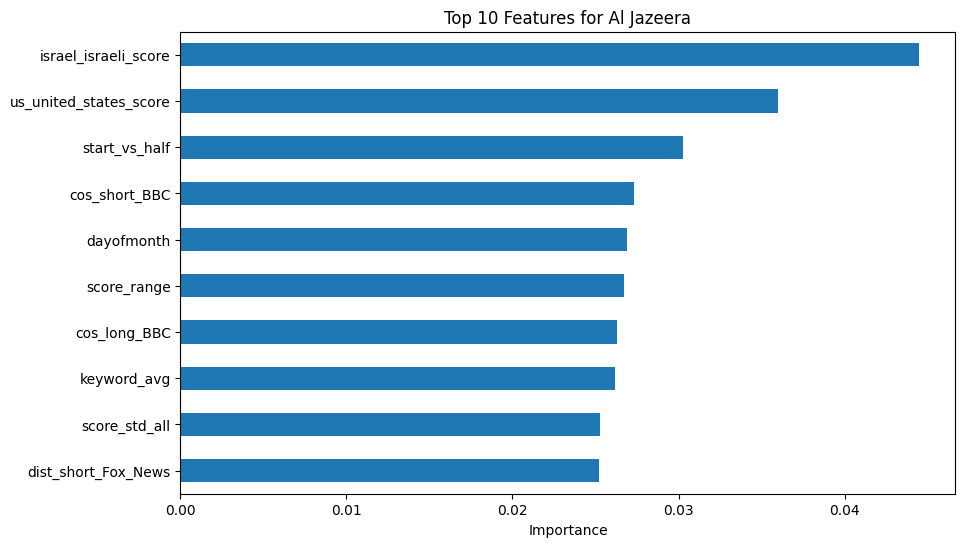

In [54]:
# =========================================================
# 22. PLOT TOP FEATURES FOR ONE PUBLISHER
# =========================================================

publisher_to_plot = sorted(df["publisher"].unique())[0]

if publisher_importance and publisher_to_plot in publisher_importance:
    plt.figure(figsize=(10, 6))
    publisher_importance[publisher_to_plot].head(10).sort_values().plot(kind="barh")
    plt.title(f"Top 10 Features for {publisher_to_plot}")
    plt.xlabel("Importance")
    plt.show()
else:
    print(f"Publisher '{publisher_to_plot}' not found in publisher_importance.")

# 23. Compare True Class Balance to Predicted Class Balance

This helps check whether the model is over-predicting any one publisher.

In [55]:
# =========================================================
# 23. CHECK TRUE VS PREDICTED CLASS BALANCE
# =========================================================

print("True publisher distribution:")
print(df["publisher"].value_counts(normalize=True))

if not predictions_df.empty:
    print("\nPredicted publisher distribution:")
    print(predictions_df["predicted_publisher"].value_counts(normalize=True))
else:
    print("\nNo predictions available.")

True publisher distribution:
publisher
Al Jazeera    0.318919
BBC           0.256757
NBC News      0.240541
Fox News      0.183784
Name: proportion, dtype: float64

Predicted publisher distribution:
predicted_publisher
Al Jazeera    0.332370
BBC           0.271676
NBC News      0.210983
Fox News      0.184971
Name: proportion, dtype: float64


# 24. Notes

Suggested experiments to compare:

1. short-term window = 3 days
2. short-term window = 5 days
3. raw score columns only
4. raw + derived features
5. raw + derived + profile comparison features

This will help show which setup gives the best live daily accuracy.